In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import re
import csv
import codecs
import urllib.request
import urllib.error
import sys
from dotenv import load_dotenv

### 1 file

In [144]:
sunflower_df = pd.read_csv("./data_1/2022_sunflower.csv")

In [143]:
sunflower_df.head()

,DISTANCE,SWATHWIDTH,VRYIELDMAS,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,...,Fe,Zn,S,P,P_Index,K,K_Index,Na,pH,C.E.C
0,2.94795,9.300004,1.305388,-1201171,22,1.305388,7.7,10/9/2022 5:38:03 PM,27.358735,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
1,2.88906,9.300004,1.276285,-1201171,22,1.276285,7.8,10/9/2022 5:38:04 PM,26.132605,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
2,2.86502,9.300004,1.346578,-1201171,22,1.346578,7.7,10/9/2022 5:38:05 PM,24.992419,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
3,2.38688,9.300004,1.632671,-1201171,22,1.632671,7.7,10/9/2022 5:38:06 PM,24.556971,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
4,2.24921,9.300004,1.431187,-1201171,22,1.431187,7.7,10/9/2022 5:38:07 PM,25.479433,Sunflowers,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5


In [133]:
sunflower_df['SECTIONID'].unique()

array([-1201171, -2386833,  -134330], dtype=int64)

<Axes: title={'center': 'Plot of Column VRYIELDMAS'}>

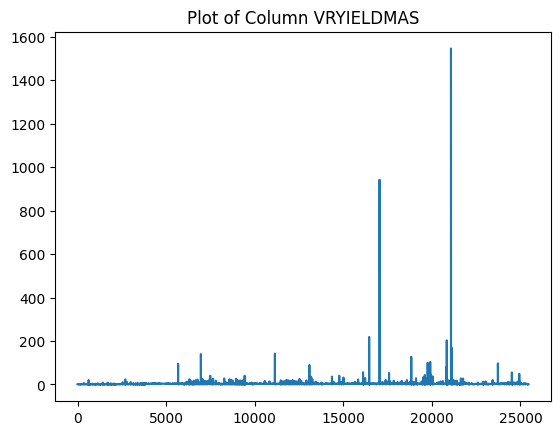

In [134]:
column = 'VRYIELDMAS'
sunflower_df[column].plot(kind='line', title=f'Plot of Column {column}')

In [89]:
print(sunflower_df[column].describe())

count    25455.000000
mean         2.964375
std         11.889113
min          0.003155
25%          1.962196
50%          2.933153
75%          3.441555
max       1546.409630
Name: VRYIELDMAS, dtype: float64


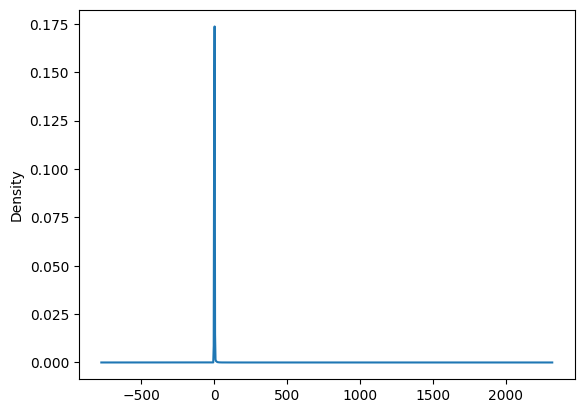

In [135]:
sunflower_df[column].plot.density()
plt.show()

<Axes: >

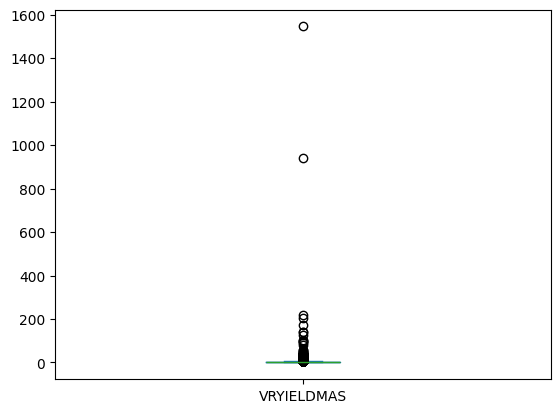

In [91]:
sunflower_df[column].plot.box()

Lower bound: -0.25684158999999984
Upper bound: 5.6605928500000005


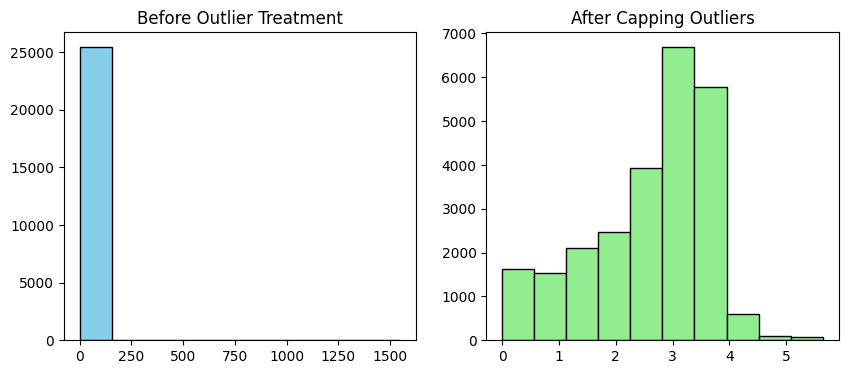

In [136]:
col = sunflower_df[column].astype(float) 
Q1 = np.percentile(col, 25)
Q3 = np.percentile(col, 75)
IQR = Q3 - Q1
MEAN = sunflower_df[column].mean()

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

sunflower_df_ = sunflower_df[
    (sunflower_df[column] >= lower_bound) &
    (sunflower_df[column] <= upper_bound)
]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(sunflower_df[column], bins=10, color="skyblue", edgecolor="black")
plt.title("Before Outlier Treatment")
plt.subplot(1,2,2)
plt.hist(sunflower_df_[column], bins=10, color="lightgreen", edgecolor="black")
plt.title("After Capping Outliers")
plt.show()

In [137]:
print(sunflower_df_[column].describe())

count    24897.000000
mean         2.600782
std          1.066422
min          0.003155
25%          1.928172
50%          2.905378
75%          3.408583
max          5.641562
Name: VRYIELDMAS, dtype: float64


In [138]:
len(sunflower_df_)

24897

[]

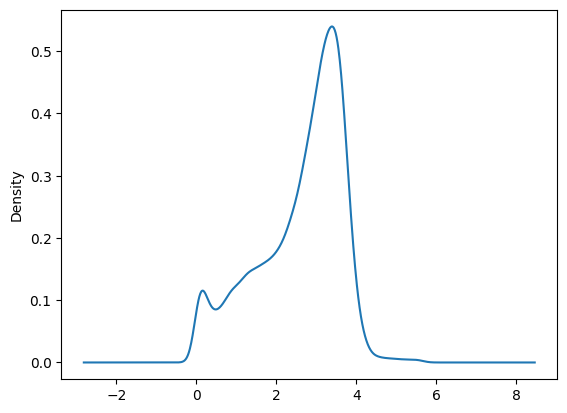

In [139]:
sunflower_df_[column].plot.density()
plt.plot()

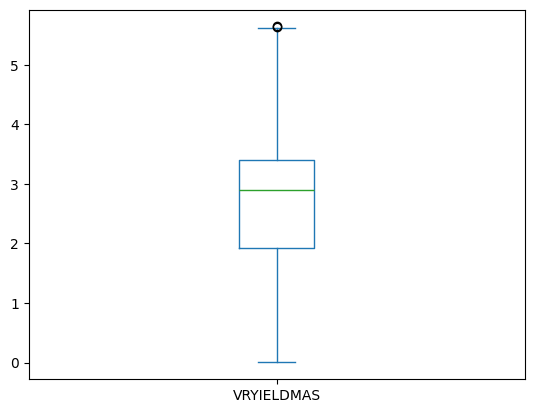

In [95]:
sunflower_df_[column].plot.box()
plt.show()

In [59]:
max_width = sunflower_df["SWATHWIDTH"].max()
print(max_width)

11.20000529


In [96]:
sunflower_df_.columns

Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'FUEL', 'VEHICLSPEED', 'DRYMATTER', 'PRODUCTHASH', 'xcoord',
       'ycoord', 'area', 'CROPNAME_', 'FIELDREF', 'Organic M', 'Ca', 'Mg',
       'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P', 'P_Index', 'K',
       'K_Index', 'Na', 'pH', 'C.E.C'],
      dtype='object')

In [145]:
clear_sunflower_df = sunflower_df_.drop(columns=['FIELDREF', 'DISTANCE', 'SWATHWIDTH', 'WetMass', 'Time', 'Heading', 'VARIETY', 'IsoTime', 'Machine', 'FUEL', 'VEHICLSPEED', 'PRODUCTHASH'])
clear_sunflower_df.head()

,VRYIELDMAS,SECTIONID,Crop,Moisture,Elevation,DRYMATTER,xcoord,ycoord,area,CROPNAME_,...,Fe,Zn,S,P,P_Index,K,K_Index,Na,pH,C.E.C
0,1.305388,-1201171,22,7.7,83.607,92.3,25.837112,48.828905,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
1,1.276285,-1201171,22,7.8,83.485,92.2,25.837130,48.828928,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
2,1.346578,-1201171,22,7.7,83.332,92.3,25.837147,48.828951,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
3,1.632671,-1201171,22,7.7,83.210,92.3,25.837160,48.828970,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5
4,1.431187,-1201171,22,7.7,83.119,92.3,25.837173,48.828989,6.03,Maize,...,68.0,1.7,2.0,8.0,0.8,375.0,3.8,11.0,8.1,23.5


In [ ]:
clear_sunflower_df = clear_sunflower_df.dropna()
# clear_sunflower_df = clear_sunflower_df.drop(columns=['SECTIONID'])
# clear_sunflower_df.columns

In [28]:
# clear_sunflower_df.head

In [147]:
clear_sunflower_df.to_csv('./data_1/2022_sunflower_.csv', index=False)

### Погода

In [21]:
BaseURL = 'https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/'

In [22]:
load_dotenv() 
API_KEY = os.getenv("API_KEY")
# print(API_KEY)

 ('2021-05-01', '2021-11-04'), ('2022-05-01', '2022-10-09'), ('2023-05-01', '2023-11-03'), ('2024-05-01', '2024-09-11')

In [23]:
UnitGroup='metric'
Location='Ternopil,UK'
StartDate = '2024-05-01'
EndDate='2024-10-31'
ContentType="csv"
Include="days"

In [24]:
ApiQuery = BaseURL + Location

if (len(StartDate)):
    ApiQuery += "/" + StartDate
    if (len(EndDate)):
        ApiQuery += "/" + EndDate

ApiQuery += "?"

if (len(UnitGroup)):
    ApiQuery += "&unitGroup=" + UnitGroup

if (len(ContentType)):
    ApiQuery += "&contentType=" + ContentType

if (len(Include)):
    ApiQuery += "&include=" + Include

ApiQuery += "&key=" + API_KEY

print(' - Running query URL: ', ApiQuery)
print()

try:
    CSVBytes = urllib.request.urlopen(ApiQuery)
except urllib.error.HTTPError as e:
    ErrorInfo = e.read().decode()
    print('Error code: ', e.code, ErrorInfo)
    sys.exit()
except urllib.error.URLError as e:
    ErrorInfo = e.read().decode()
    print("Error code: ", e.code, ErrorInfo)
    sys.exit()

 - Running query URL:  https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/Ternopil,UK/2024-05-01/2024-10-31?&unitGroup=metric&contentType=csv&include=days&key=BF2FAXQDLMNR4558X2Q84AZZ6



In [ ]:
CSVText = csv.reader(codecs.iterdecode(CSVBytes, 'utf-8'))

with open("weather_data_2024.csv", "w", encoding="utf-8", newline="") as file:
    writer = csv.writer(file)
    for row in CSVText:
        writer.writerow(row)

In [87]:
weather_df = pd.DataFrame()

folder_path = './data_1/weather_data'
regex = r"^weather_data_\d{4}\.csv$"

all_data_frames = []
file_list = os.listdir(folder_path)

for i in file_list:
    if re.search(regex, i):
        year = (i.split('_')[2])
        year_ = int(year.split('.')[0])
        new_df = pd.read_csv(os.path.join(folder_path, i))
        new_df['year'] = year_
        all_data_frames.append(new_df)
        weather_df = pd.concat([weather_df, new_df], ignore_index=True)

weather_df.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations,year
0,"Тернопіль, Україна",2018-05-01,28.2,10.2,19.2,27.1,10.2,19.0,9.3,56.3,...,8.0,NaN,2018-05-01T05:55:41,2018-05-01T20:34:49,0.54,"Rain, Partially cloudy",Becoming cloudy in the afternoon with late aft...,rain,"33415099999,remote",2018
1,"Тернопіль, Україна",2018-05-02,28.6,10.1,20.1,27.6,10.1,20.0,11.4,61.8,...,8.0,NaN,2018-05-02T05:53:56,2018-05-02T20:36:19,0.58,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,"33415099999,remote",2018
2,"Тернопіль, Україна",2018-05-03,28.3,9.7,20.8,26.9,9.7,20.5,6.3,44.0,...,8.0,NaN,2018-05-03T05:52:14,2018-05-03T20:37:49,0.61,Clear,Clear conditions throughout the day.,clear-day,"33415099999,remote",2018
3,"Тернопіль, Україна",2018-05-04,29.7,11.6,21.7,28.1,11.6,21.3,8.4,47.0,...,8.0,NaN,2018-05-04T05:50:33,2018-05-04T20:39:18,0.64,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"33415099999,remote",2018
4,"Тернопіль, Україна",2018-05-05,24.8,13.7,19.6,24.8,13.7,19.6,11.7,62.1,...,8.0,NaN,2018-05-05T05:48:53,2018-05-05T20:40:47,0.67,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"33415099999,remote",2018


In [88]:
weather_df.columns

Index(['name', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations',
       'year'],
      dtype='object')

In [89]:
weather_df.isna().sum()

name                   0
datetime               0
tempmax                0
tempmin                0
temp                   0
feelslikemax           0
feelslikemin           0
feelslike              0
dew                    0
humidity               0
precip                 0
precipprob             0
precipcover            0
preciptype           435
snow                   0
snowdepth              0
windgust               0
windspeed              0
winddir                0
sealevelpressure       0
cloudcover             0
visibility             3
solarradiation         1
solarenergy            1
uvindex                1
severerisk          1082
sunrise                0
sunset                 0
moonphase              0
conditions             0
description            0
icon                   0
stations               0
year                   0
dtype: int64

In [90]:
weather_df["tempmax"].isna().sum()

0

In [91]:
weather_df["tempmin"].isna().sum()

0

In [92]:
weather_df["temp"].isna().sum()

0

In [93]:
weather_df["humidity"].isna().sum()

0

In [94]:
weather_df["precip"].isna().sum()

0

In [95]:
weather_df["cloudcover"].isna().sum()

0

In [96]:
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])
weather_df['month'] = weather_df['datetime'].dt.month

weather_df_ = weather_df.groupby(['year', 'month']).agg(
    max_tempmax = ("tempmax", "max"), 
    min_tempmax = ("tempmax", "min"), 
    mean_tempmax = ("tempmax", "mean"),
    std_tempmax = ("tempmax", "std"), 

    max_tempmin = ("tempmin", "max"), 
    min_tempmin = ("tempmin", "min"), 
    mean_tempmin = ("tempmin", "mean"), 
    std_tempmin = ("tempmin", "std"), 

    max_temp = ("temp", "max"), 
    min_temp = ("temp", "min"), 
    mean_temp = ("temp", "mean"),
    std_temp = ("temp", "std"), 
    
    max_humidity = ("humidity", "max"), 
    min_humidity = ("humidity", "min"), 
    mean_humidity = ("humidity", "mean"), 
    std_humidity = ("humidity", "std"), 

    max_precip = ("precip", "max"), 
    min_precip = ("precip", "min"), 
    mean_precip = ("precip", "mean"), 
    std_precip = ("precip", "std"), 

    max_cloudcover = ("cloudcover", "max"), 
    min_cloudcover = ("cloudcover", "min"), 
    mean_cloudcover = ("cloudcover", "mean"),
    std_cloudcover = ("cloudcover", "std"), 
).reset_index()

In [97]:
weather_df_

,year,month,max_tempmax,min_tempmax,mean_tempmax,std_tempmax,max_tempmin,min_tempmin,mean_tempmin,std_tempmin,...,mean_humidity,std_humidity,max_precip,min_precip,mean_precip,std_precip,max_cloudcover,min_cloudcover,mean_cloudcover,std_cloudcover
0,2018,5,29.7,14.9,23.019355,4.256244,14.1,6.2,10.716129,2.139485,...,61.187097,12.818001,20.0,0.0,1.525806,3.726926,89.1,1.3,47.229032,24.902733
1,2018,6,29.9,12.6,23.656667,4.093197,17.8,7.6,13.456667,2.673843,...,71.913333,12.960038,23.0,0.0,3.340000,5.368465,99.0,12.0,68.313333,24.864623
2,2018,7,29.3,15.4,24.283871,3.147708,18.6,9.0,14.935484,2.592238,...,77.409677,8.851454,26.0,0.0,3.725806,6.168899,96.4,29.6,67.474194,18.293386
3,2018,8,29.8,18.1,26.403226,2.787051,18.4,10.2,14.664516,2.048503,...,70.677419,8.075961,8.0,0.0,1.270968,2.225188,99.5,5.2,48.309677,24.280985
4,2018,9,29.9,9.6,21.266667,5.365428,14.4,-0.3,9.760000,3.674760,...,71.666667,7.180449,18.0,0.0,1.513333,3.638845,98.3,10.2,59.550000,24.648883
5,2018,10,22.9,6.9,16.103226,4.502406,9.3,-0.3,4.809677,2.583583,...,76.593548,8.174429,10.0,0.0,1.080645,2.340857,92.1,0.0,47.425806,34.175800
6,2020,5,27.4,7.6,16.180645,4.130490,11.7,-0.4,6.354839,2.802242,...,70.861290,12.004101,19.0,0.0,3.167742,5.623782,99.0,27.3,70.983871,20.389051
7,2020,6,29.9,11.0,23.646667,4.356029,18.4,5.7,14.603333,3.304488,...,78.540000,8.125762,19.0,0.0,4.250000,4.763710,97.2,40.3,73.043333,15.075481
8,2020,7,30.1,17.6,24.551613,3.286424,18.3,7.7,13.477419,2.669545,...,74.054839,7.098020,22.0,0.0,1.732258,3.958399,89.4,13.7,60.516129,20.282194
9,2020,8,32.8,20.5,26.777419,3.005962,17.5,8.4,13.422581,2.638018,...,65.761290,8.563904,11.1,0.0,1.112903,2.504761,81.8,9.6,47.380645,19.390555


In [98]:
weather_df_.isna().sum()

year               0
month              0
max_tempmax        0
min_tempmax        0
mean_tempmax       0
std_tempmax        0
max_tempmin        0
min_tempmin        0
mean_tempmin       0
std_tempmin        0
max_temp           0
min_temp           0
mean_temp          0
std_temp           0
max_humidity       0
min_humidity       0
mean_humidity      0
std_humidity       0
max_precip         0
min_precip         0
mean_precip        0
std_precip         0
max_cloudcover     0
min_cloudcover     0
mean_cloudcover    0
std_cloudcover     0
dtype: int64

###

In [99]:
wether_table = weather_df_.pivot(
    index="year", 
    columns="month", 
    values=[
        'max_tempmax',
        'min_tempmax',
        'mean_tempmax',	
        'std_tempmax',

        'max_tempmin',
        'min_tempmin',
        'mean_tempmin',
        'std_tempmin', 

        'max_temp',
        'min_temp',
        'mean_temp',
        'std_temp', 

        'max_humidity',	
        'min_humidity',
        'mean_humidity',
        'std_humidity', 

        'max_precip',
        'min_precip',
        'mean_precip',
        'std_precip', 

        'max_cloudcover',
        'min_cloudcover',
        'mean_cloudcover',
        'std_cloudcover'
    ]
)

In [100]:
wether_table

max_tempmax                               min_tempmax                    \
month          5     6     7     8     9     10          5     6     7     8    
year                                                                            
2018         29.7  29.9  29.3  29.8  29.9  22.9        14.9  12.6  15.4  18.1   
2020         27.4  29.9  30.1  32.8  30.7  21.8         7.6  11.0  17.6  20.5   
2021         23.2  32.4  34.1  29.6  25.1  19.5         9.4  15.4  19.9  13.4   
2022         29.3  33.9  33.4  31.4  22.9  20.7        14.7  19.1  17.8  19.7   
2023         26.4  29.2  32.2  34.9  28.9  25.4         8.9  11.4  17.9  19.7   
2024         26.8  32.8  35.9  32.9  29.9  22.6        14.4  16.2  16.2  21.2   

       ... mean_cloudcover                                  std_cloudcover  \
month  ...              7          8          9          10             5    
year   ...                                                                   
2018   ...       67.474194  48.309677  59.550000  47.425806      24.902733   
2020   ...       60.516129  47.380645  49.096667  85.480645      20.389051   
2021   ...       54.719355  59.800000  65.043333  48.183871      25.594998   
2022   ...       57.148387  58.135484  82.520000  69.633333      20.486173   
2023   ...       61.551613  46.777419  42.996667  70.322581      28.547902   
2024   ...       56.635484  43.606452  53.983333  61.748387      24.192672   

                                                              
month         6          7          8          9          10  
year                                                          
2018   24.864623  18.293386  24.280985  24.648883  34.175800  
2020   15.075481  20.282194  19.390555  29.610814  13.894901  
2021   21.686078  27.606586  23.888658  26.689152  30.516139  
2022   24.235914  22.721163  27.867000  19.940729  24.506224  
2023   25.913016  23.104485  21.398858  31.044867  16.965783  
2024   21.986699  22.469365  27.514880  35.865708  33.080930  

[6 rows x 144 columns]

In [101]:
wether_table.isna().sum()

                month
max_tempmax     5        0
                6        0
                7        0
                8        0
                9        0
                        ..
std_cloudcover  6        0
                7        0
                8        0
                9        0
                10       0
Length: 144, dtype: int64

In [102]:
wether_table.columns

MultiIndex([(    'max_tempmax',  5),
            (    'max_tempmax',  6),
            (    'max_tempmax',  7),
            (    'max_tempmax',  8),
            (    'max_tempmax',  9),
            (    'max_tempmax', 10),
            (    'min_tempmax',  5),
            (    'min_tempmax',  6),
            (    'min_tempmax',  7),
            (    'min_tempmax',  8),
            ...
            ('mean_cloudcover',  7),
            ('mean_cloudcover',  8),
            ('mean_cloudcover',  9),
            ('mean_cloudcover', 10),
            ( 'std_cloudcover',  5),
            ( 'std_cloudcover',  6),
            ( 'std_cloudcover',  7),
            ( 'std_cloudcover',  8),
            ( 'std_cloudcover',  9),
            ( 'std_cloudcover', 10)],
           names=[None, 'month'], length=144)

In [103]:
wether_table.columns = [
f"{feature}_month_{month}" 
for feature, month in wether_table.columns
]

wether_table = wether_table.reset_index()

In [104]:
wether_table.head()

,year,max_tempmax_month_5,max_tempmax_month_6,max_tempmax_month_7,max_tempmax_month_8,max_tempmax_month_9,max_tempmax_month_10,min_tempmax_month_5,min_tempmax_month_6,min_tempmax_month_7,...,mean_cloudcover_month_7,mean_cloudcover_month_8,mean_cloudcover_month_9,mean_cloudcover_month_10,std_cloudcover_month_5,std_cloudcover_month_6,std_cloudcover_month_7,std_cloudcover_month_8,std_cloudcover_month_9,std_cloudcover_month_10
0,2018,29.7,29.9,29.3,29.8,29.9,22.9,14.9,12.6,15.4,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.175800
1,2020,27.4,29.9,30.1,32.8,30.7,21.8,7.6,11.0,17.6,...,60.516129,47.380645,49.096667,85.480645,20.389051,15.075481,20.282194,19.390555,29.610814,13.894901
2,2021,23.2,32.4,34.1,29.6,25.1,19.5,9.4,15.4,19.9,...,54.719355,59.800000,65.043333,48.183871,25.594998,21.686078,27.606586,23.888658,26.689152,30.516139
3,2022,29.3,33.9,33.4,31.4,22.9,20.7,14.7,19.1,17.8,...,57.148387,58.135484,82.520000,69.633333,20.486173,24.235914,22.721163,27.867000,19.940729,24.506224
4,2023,26.4,29.2,32.2,34.9,28.9,25.4,8.9,11.4,17.9,...,61.551613,46.777419,42.996667,70.322581,28.547902,25.913016,23.104485,21.398858,31.044867,16.965783


In [105]:
wether_table

,year,max_tempmax_month_5,max_tempmax_month_6,max_tempmax_month_7,max_tempmax_month_8,max_tempmax_month_9,max_tempmax_month_10,min_tempmax_month_5,min_tempmax_month_6,min_tempmax_month_7,...,mean_cloudcover_month_7,mean_cloudcover_month_8,mean_cloudcover_month_9,mean_cloudcover_month_10,std_cloudcover_month_5,std_cloudcover_month_6,std_cloudcover_month_7,std_cloudcover_month_8,std_cloudcover_month_9,std_cloudcover_month_10
0,2018,29.7,29.9,29.3,29.8,29.9,22.9,14.9,12.6,15.4,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.175800
1,2020,27.4,29.9,30.1,32.8,30.7,21.8,7.6,11.0,17.6,...,60.516129,47.380645,49.096667,85.480645,20.389051,15.075481,20.282194,19.390555,29.610814,13.894901
2,2021,23.2,32.4,34.1,29.6,25.1,19.5,9.4,15.4,19.9,...,54.719355,59.800000,65.043333,48.183871,25.594998,21.686078,27.606586,23.888658,26.689152,30.516139
3,2022,29.3,33.9,33.4,31.4,22.9,20.7,14.7,19.1,17.8,...,57.148387,58.135484,82.520000,69.633333,20.486173,24.235914,22.721163,27.867000,19.940729,24.506224
4,2023,26.4,29.2,32.2,34.9,28.9,25.4,8.9,11.4,17.9,...,61.551613,46.777419,42.996667,70.322581,28.547902,25.913016,23.104485,21.398858,31.044867,16.965783
5,2024,26.8,32.8,35.9,32.9,29.9,22.6,14.4,16.2,16.2,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.080930


In [106]:
wether_table.isna().sum()

year                       0
max_tempmax_month_5        0
max_tempmax_month_6        0
max_tempmax_month_7        0
max_tempmax_month_8        0
                          ..
std_cloudcover_month_6     0
std_cloudcover_month_7     0
std_cloudcover_month_8     0
std_cloudcover_month_9     0
std_cloudcover_month_10    0
Length: 145, dtype: int64

### all folder

In [12]:
yield_df = pd.DataFrame()

folder_path = './data_1/'
regex = r"^\d+_.+\.csv$"

all_data_frames = []
file_list = os.listdir(folder_path)

for i in file_list:
    if re.search(regex, i):
        year = int(i.split('_')[0])
        new_df = pd.read_csv(os.path.join(folder_path, i))
        new_df['year'] = year
        all_data_frames.append(new_df)
        yield_df = pd.concat([yield_df, new_df], ignore_index=True)

yield_df.head()

,DISTANCE,SWATHWIDTH,VRYIELDMAS,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,...,C.E.C,year,Name,FUEL,VEHICLSPEED,DRYMATTER,PRODUCTHASH,FIELDREF,x_coord,y_coord
0,2.220278,4.41,0.000000,499,45,0.000000,14.38,8/19/2018 10:05:39 AM,357.280282,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.220278,2.94,0.186290,499,45,0.199154,14.41,8/19/2018 10:05:40 AM,0.453125,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.230278,2.94,0.000000,499,45,0.000000,14.44,8/19/2018 10:05:41 AM,5.653125,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.220278,2.94,0.143233,499,45,0.153195,14.45,8/19/2018 10:05:42 AM,11.403125,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.220278,2.94,0.000000,499,45,0.000000,14.24,8/19/2018 10:05:43 AM,16.413125,2,...,26.9,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
for data_frame in all_data_frames:
    print(data_frame.columns)

Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year'],
      dtype='object')
Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year'],
      dtype='object')
Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'Name', 'CROPNAME_', 'Organic 

In [14]:
for data_frame in all_data_frames:
    if "x_coord" or "y_coord" in data_frame.columns:
        data_frame.rename(columns={"x_coord": "xcoord", "y_coord" : "ycoord"}, inplace=True)

In [15]:
for data_frame in all_data_frames:
    print(data_frame.columns)

Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year'],
      dtype='object')
Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year'],
      dtype='object')
Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'Name', 'CROPNAME_', 'Organic 

In [16]:
len(yield_df)

192108

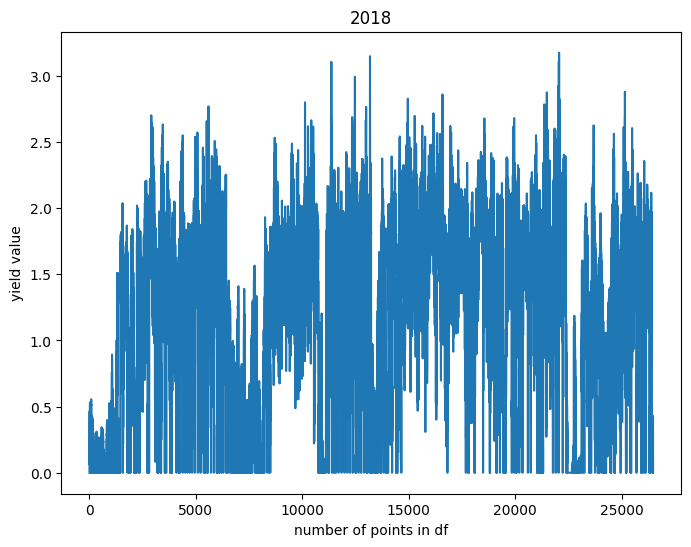

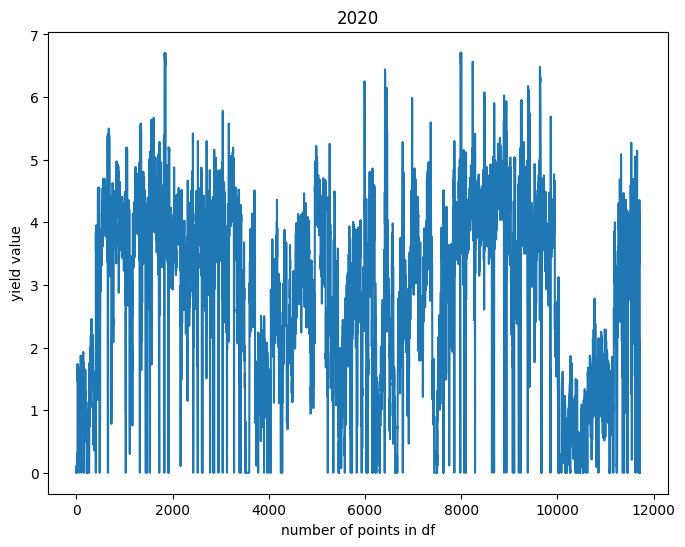

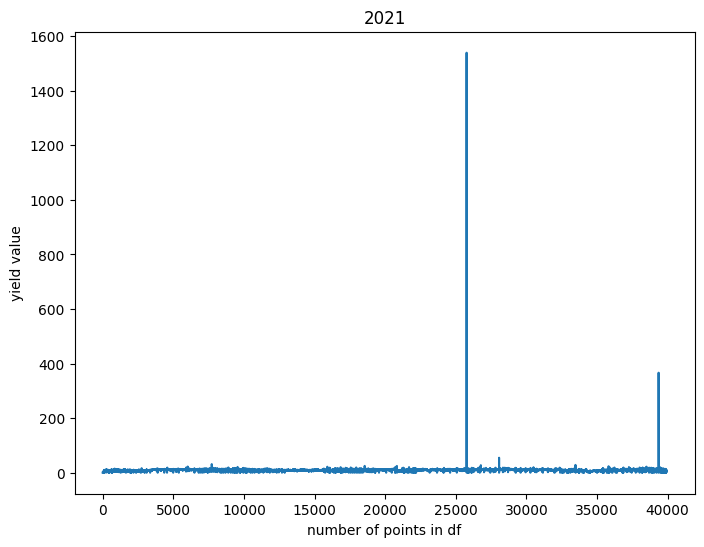

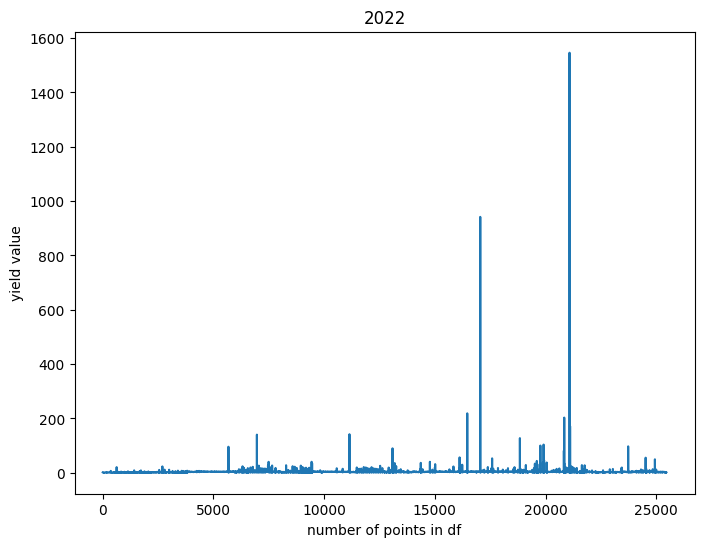

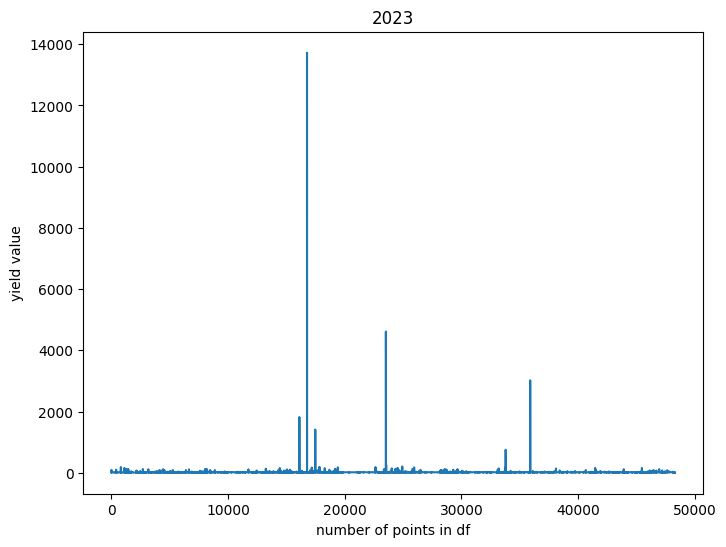

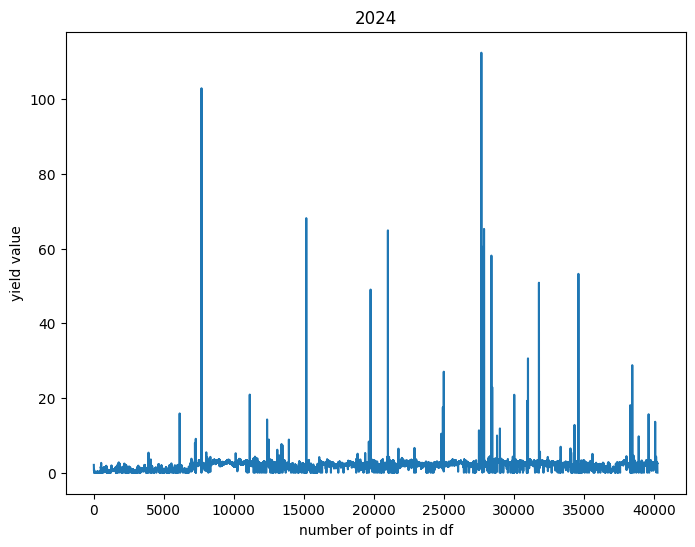

In [17]:
for i, data_frame in enumerate(all_data_frames):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot(kind='line', title=f'Plot of Column {column}')
    plt.title(f"{data_frame['year'][0]}")
    plt.xlabel("number of points in df")
    plt.ylabel("yield value")
    plt.show()

In [18]:
for i, data_frame in enumerate(all_data_frames):
    column = 'VRYIELDMAS'
    print(data_frame['year'][0])
    print(data_frame[column].describe())
    print(" ")
    print(" ")
    print(" ")

2018
count    26472.000000
mean         1.201864
std          0.719480
min          0.000000
25%          0.571064
50%          1.391113
75%          1.795620
max          3.175107
Name: VRYIELDMAS, dtype: float64
 
 
 
2020
count    11715.000000
mean         2.860205
std          1.458780
min          0.000000
25%          1.714927
50%          3.202201
75%          3.981492
max          6.708328
Name: VRYIELDMAS, dtype: float64
 
 
 
2021
count    39907.000000
mean         9.582898
std          8.466820
min          0.000000
25%          8.095449
50%          9.962961
75%         11.414709
max       1539.349227
Name: VRYIELDMAS, dtype: float64
 
 
 
2022
count    25455.000000
mean         2.964375
std         11.889113
min          0.003155
25%          1.962196
50%          2.933153
75%          3.441555
max       1546.409630
Name: VRYIELDMAS, dtype: float64
 
 
 
2023
count    48291.000000
mean        14.526494
std         68.485770
min          0.000000
25%         12.608705
50%  

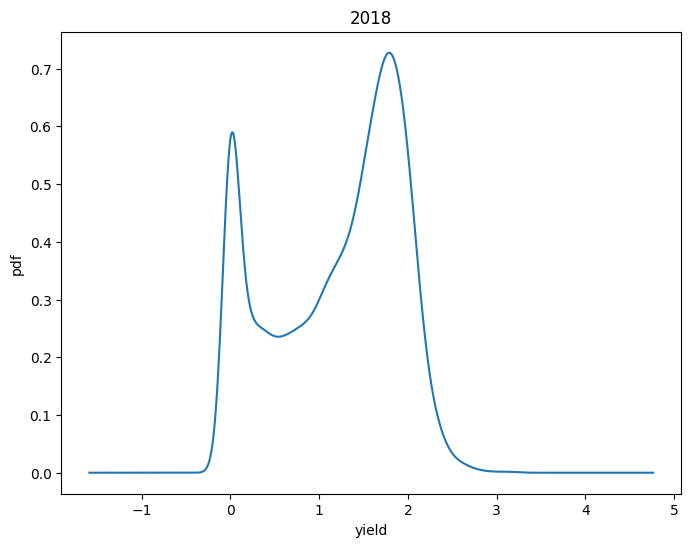

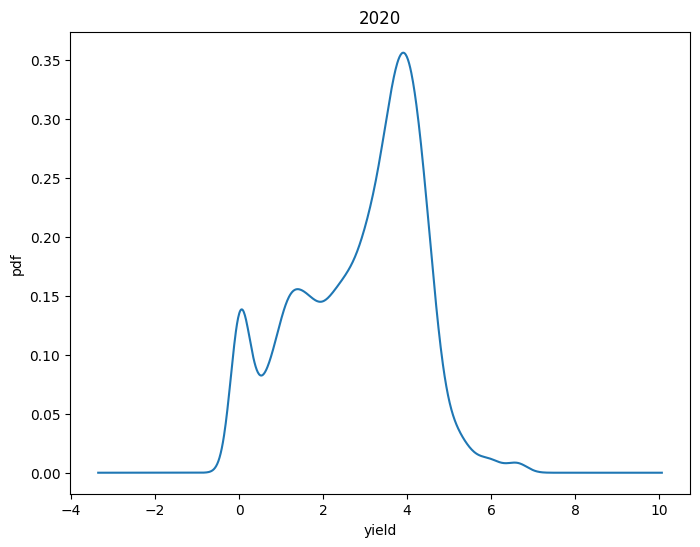

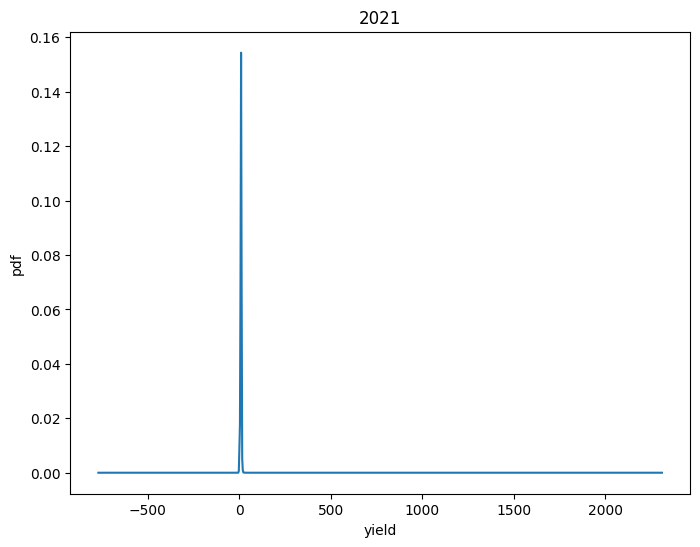

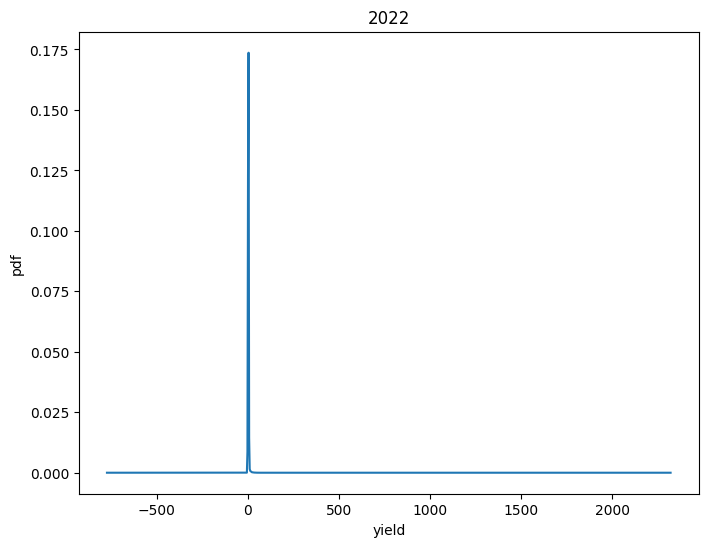

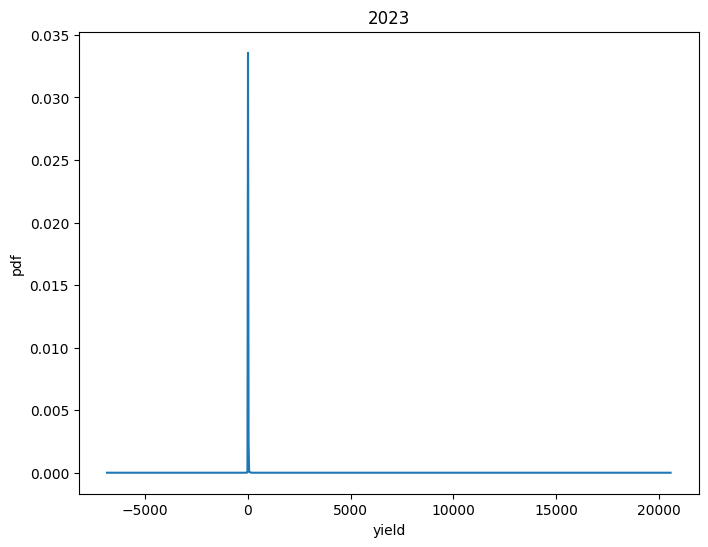

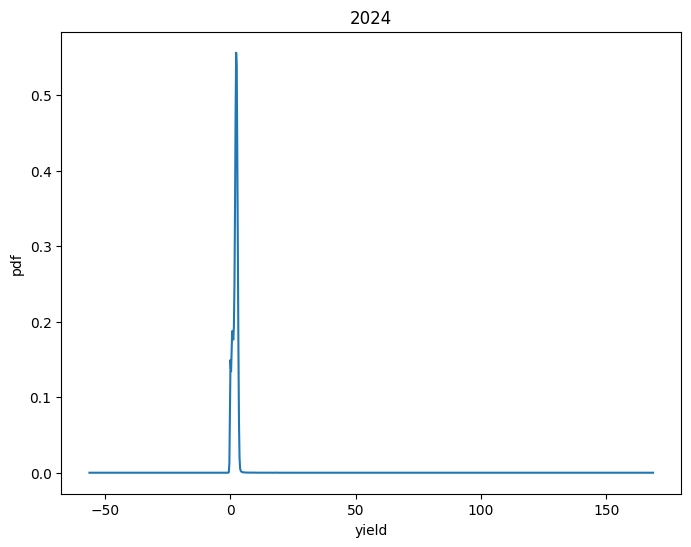

In [19]:
for i, data_frame in enumerate(all_data_frames):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot(kind='kde')
    plt.title(f"{data_frame['year'][0]}")
    plt.xlabel("yield")
    plt.ylabel("pdf")
    plt.show()

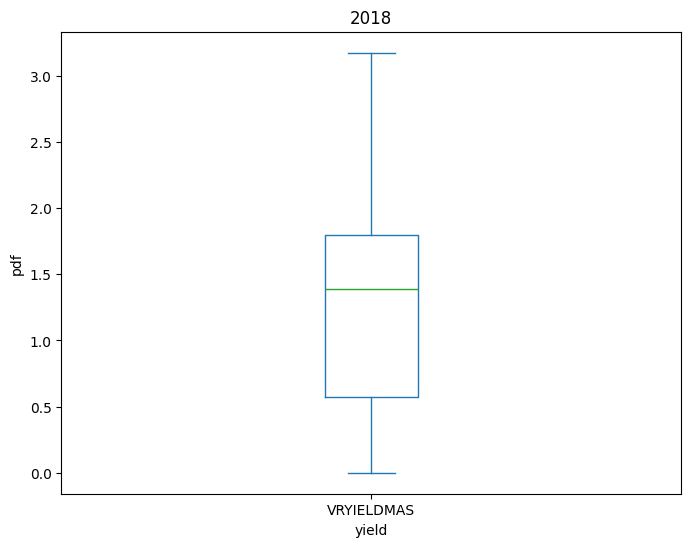

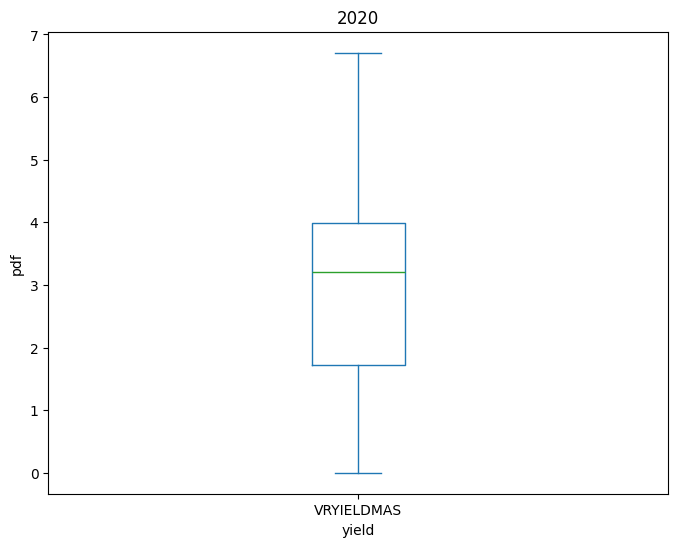

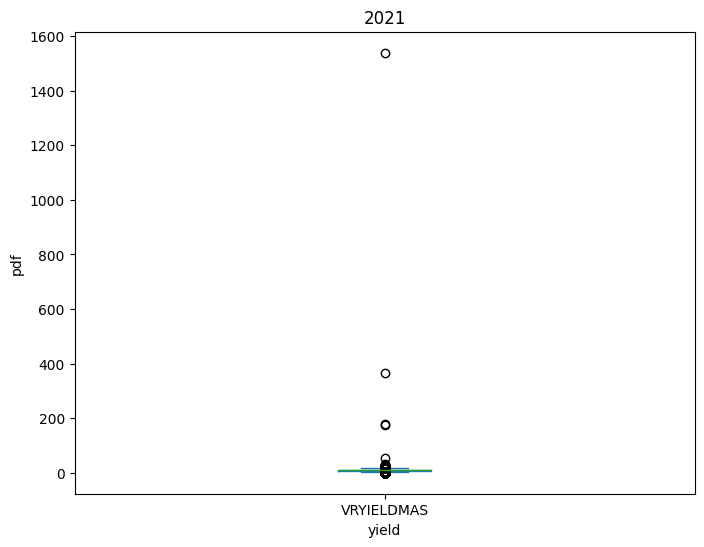

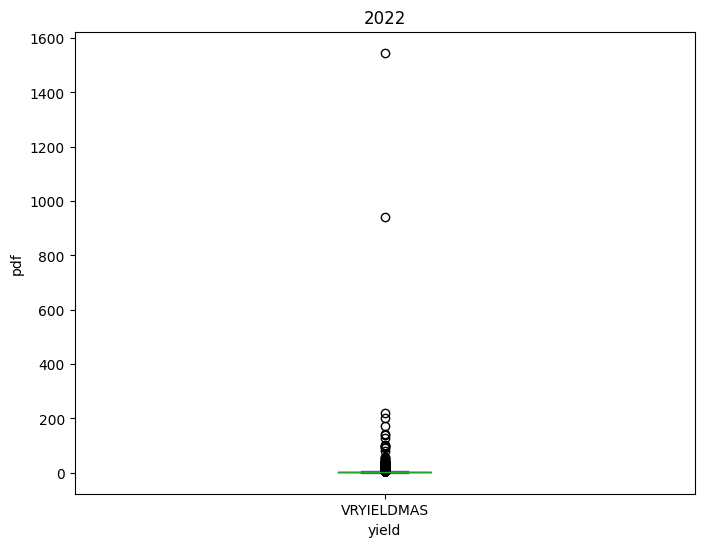

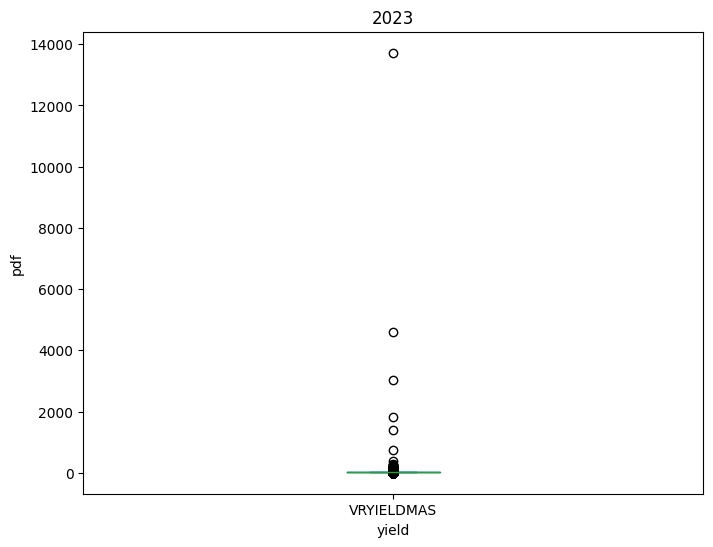

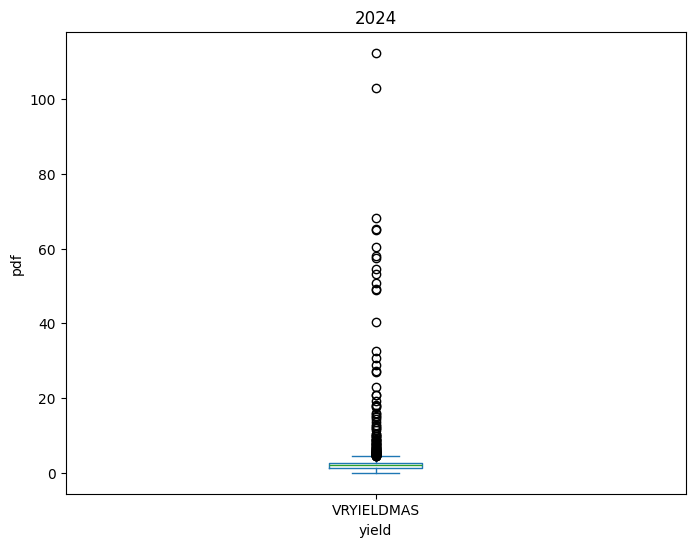

In [20]:
for i, data_frame in enumerate(all_data_frames):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot.box()
    plt.title(f"{data_frame['year'][0]}")
    plt.xlabel("yield")
    plt.ylabel("pdf")
    plt.show()

Lower bound: -1.2657696875
Upper bound: 3.6324540525


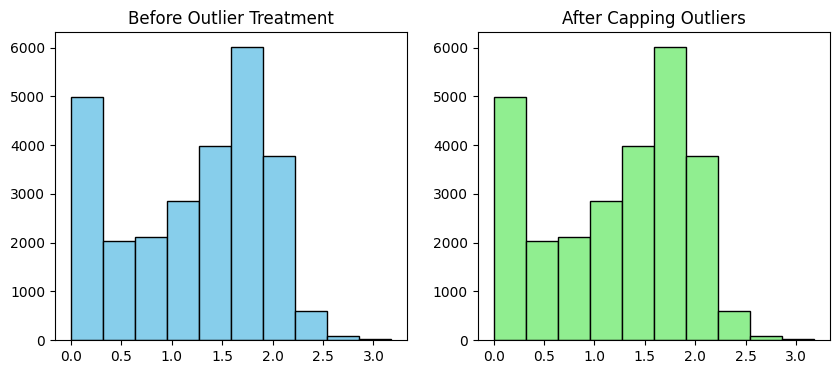

Lower bound: -1.6849189
Upper bound: 7.3813379


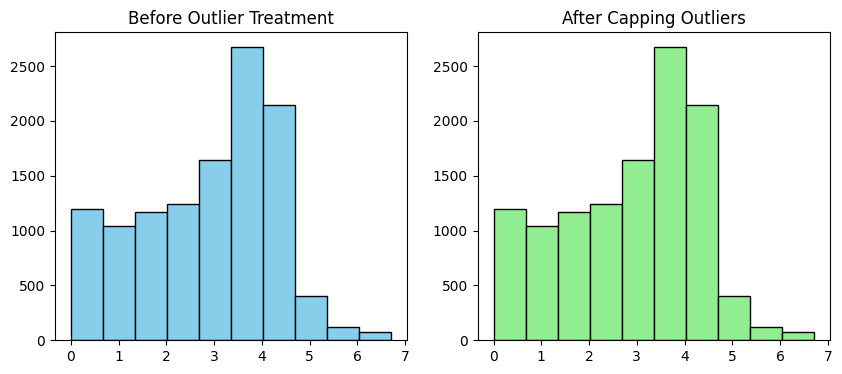

Lower bound: 3.1165600674999965
Upper bound: 16.393597567500002


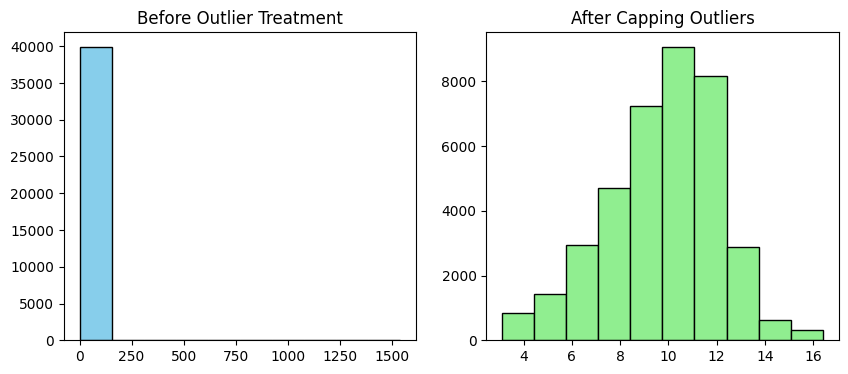

Lower bound: -0.25684158999999984
Upper bound: 5.6605928500000005


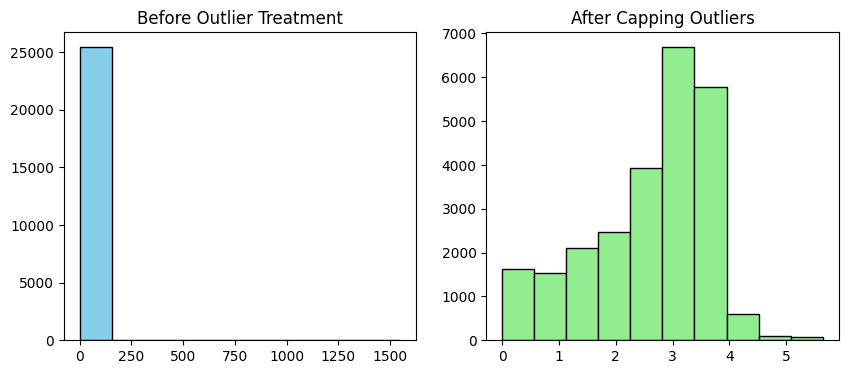

Lower bound: 8.968474085
Upper bound: 18.675757125


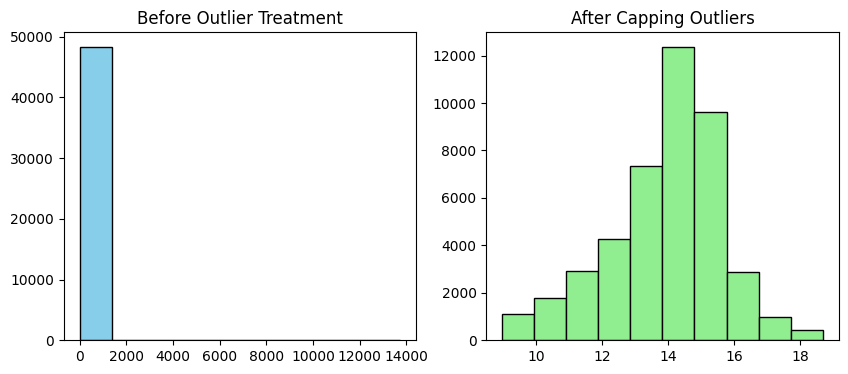

Lower bound: -0.5298486049999998
Upper bound: 4.445247634999999


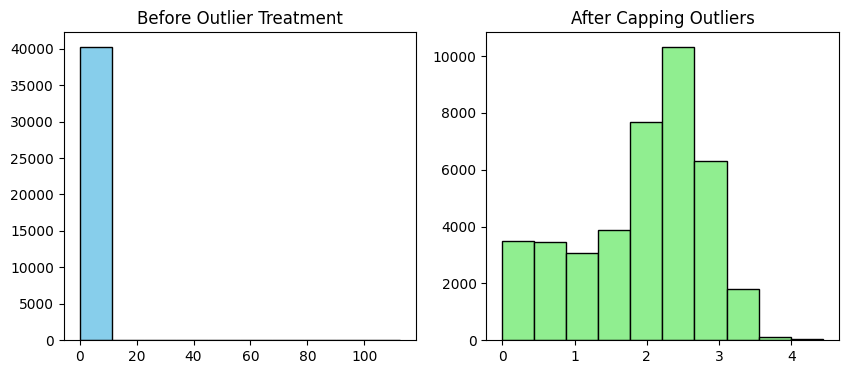

In [115]:
all_data_frames_new = []
column = 'VRYIELDMAS'

for i, data_frame in enumerate(all_data_frames):
    col = data_frame[column].astype(float) 
    Q1 = np.percentile(col, 25)
    Q3 = np.percentile(col, 75)
    IQR = Q3 - Q1
    MEAN = data_frame[column].mean()

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)

    data_frame_ = data_frame[
        (data_frame[column] >= lower_bound) &
        (data_frame[column] <= upper_bound)
    ]

    all_data_frames_new.append(data_frame_)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(data_frame[column], bins=10, color="skyblue", edgecolor="black")
    plt.title("Before Outlier Treatment")
    plt.subplot(1,2,2)
    plt.hist(data_frame_[column], bins=10, color="lightgreen", edgecolor="black")
    plt.title("After Capping Outliers")
    plt.show()

In [ ]:
for i in all_data_frames_new:
    print(len(i))

26472
11715
38209
24897
43672
40167


In [117]:
cropped_data = pd.concat(all_data_frames_new, ignore_index=True)

In [199]:
len(cropped_data)

185132

In [56]:
# all_data_frames_new[2]

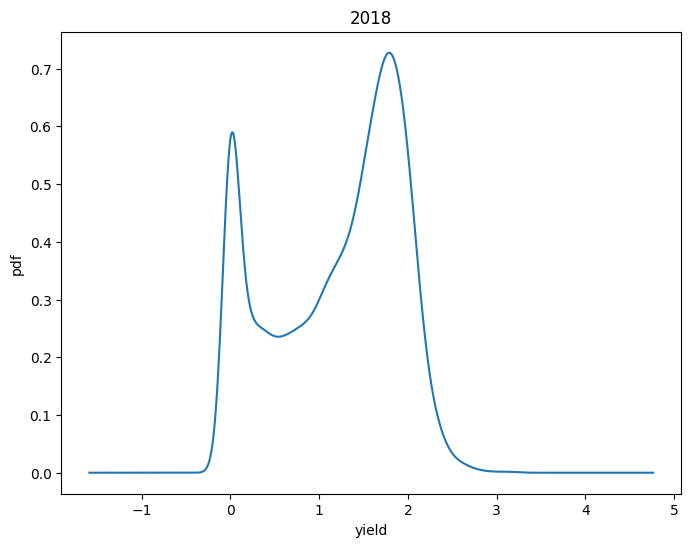

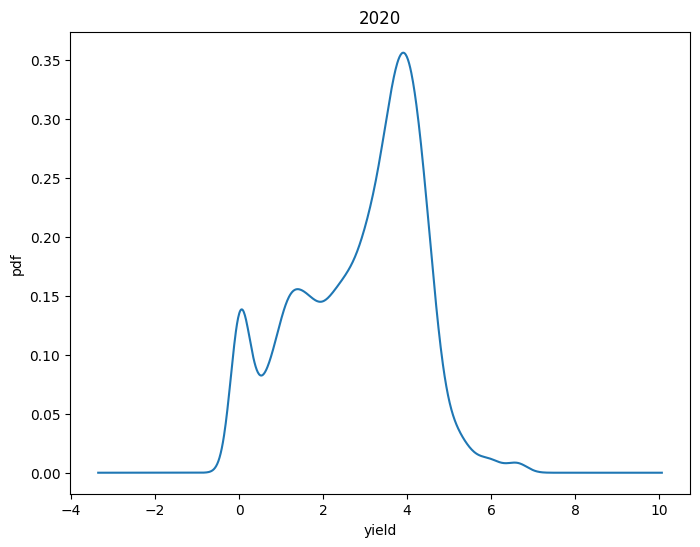

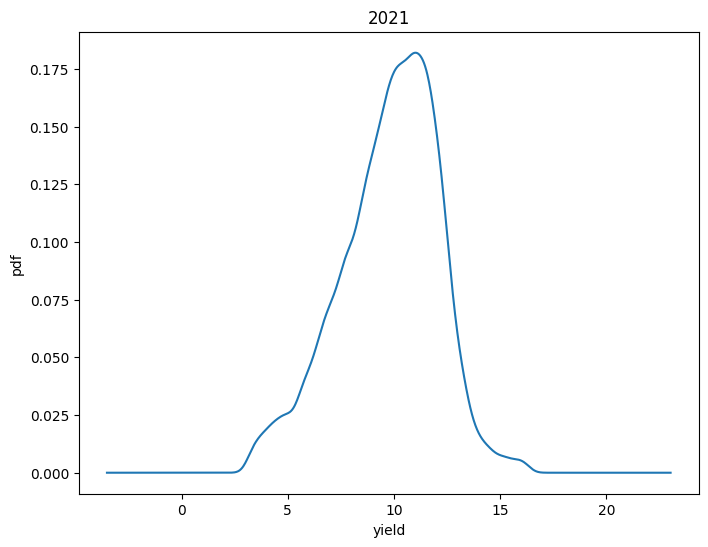

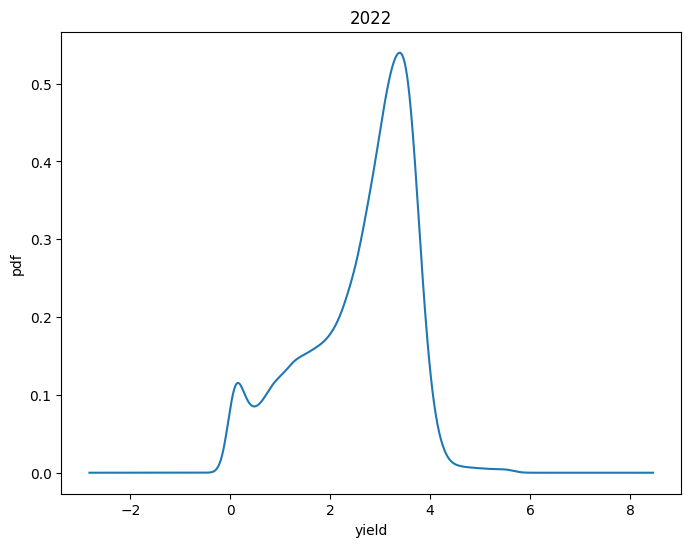

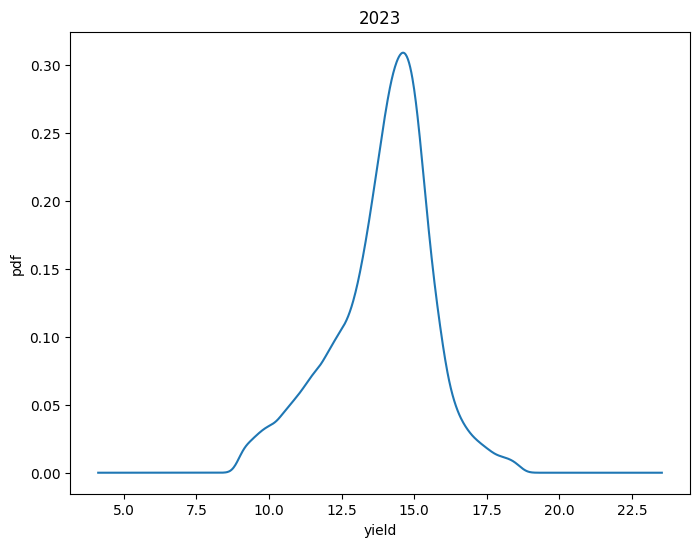

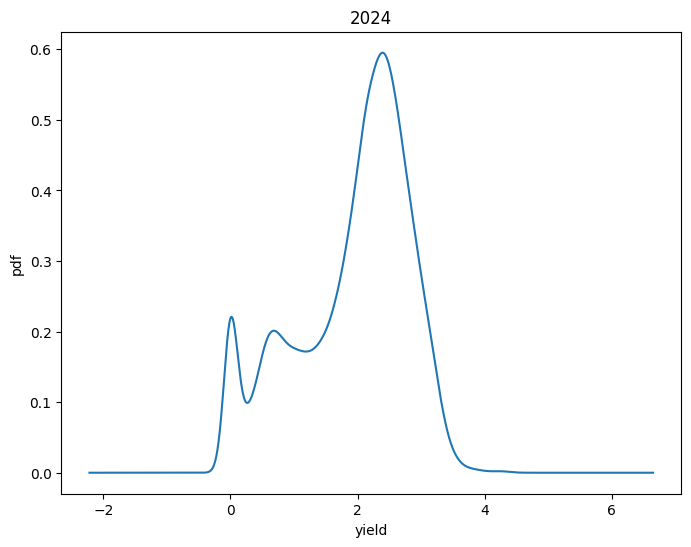

In [200]:
for i, data_frame in enumerate(all_data_frames_new):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot(kind='kde')
    plt.title(f"{data_frame['year'][100]}")
    plt.xlabel("yield")
    plt.ylabel("pdf")
    plt.show()

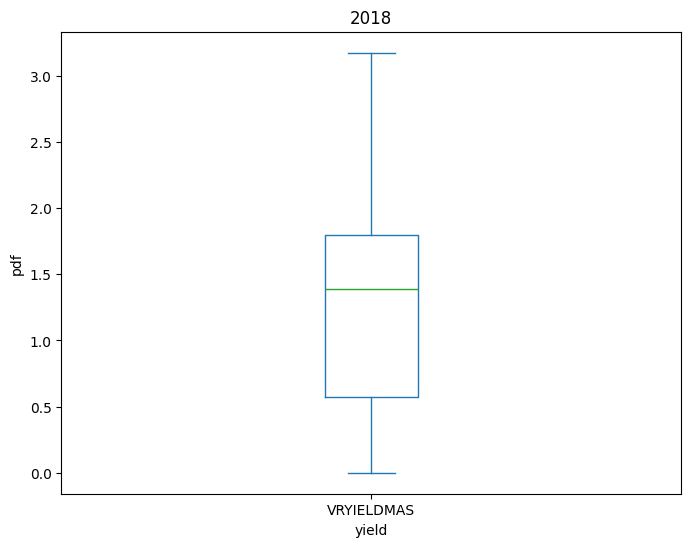

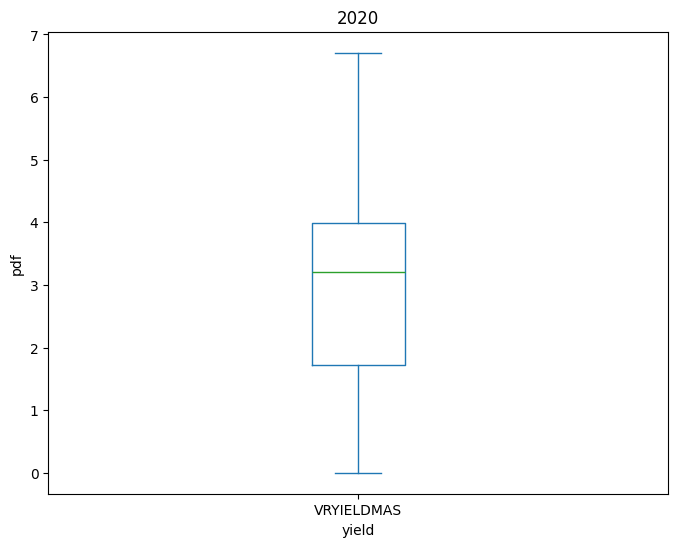

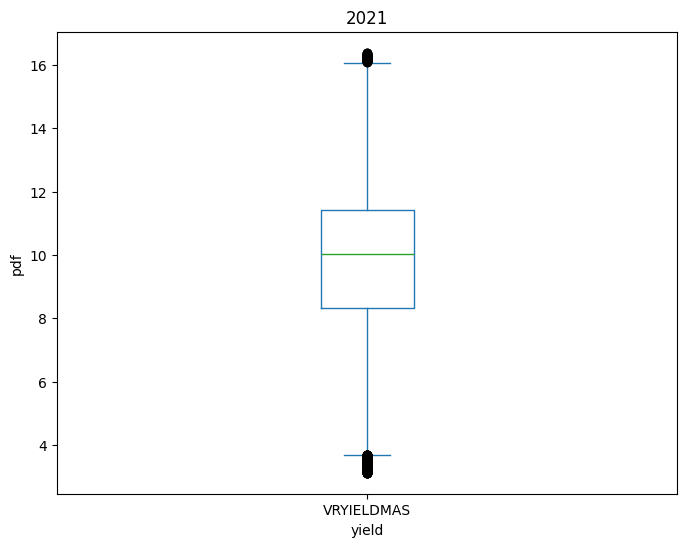

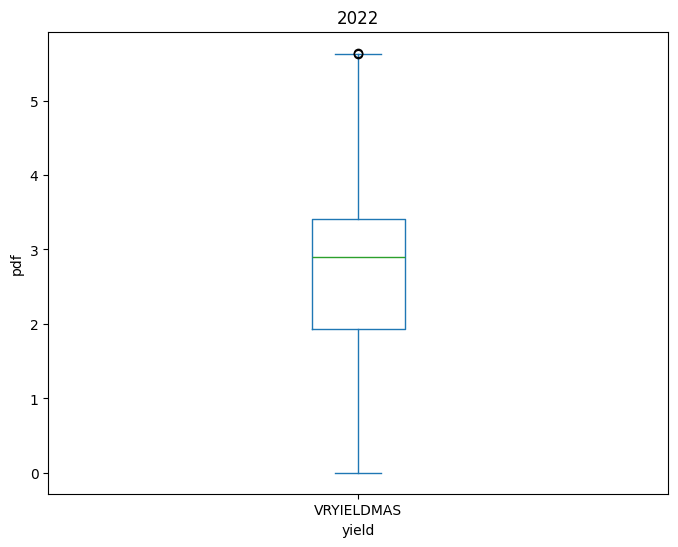

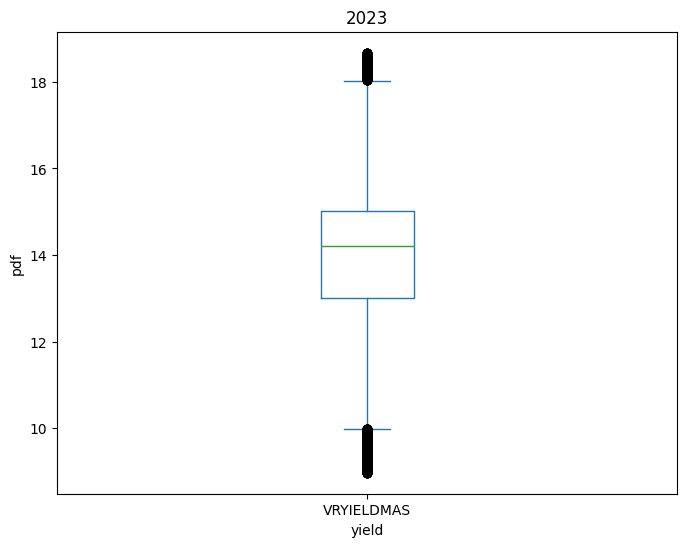

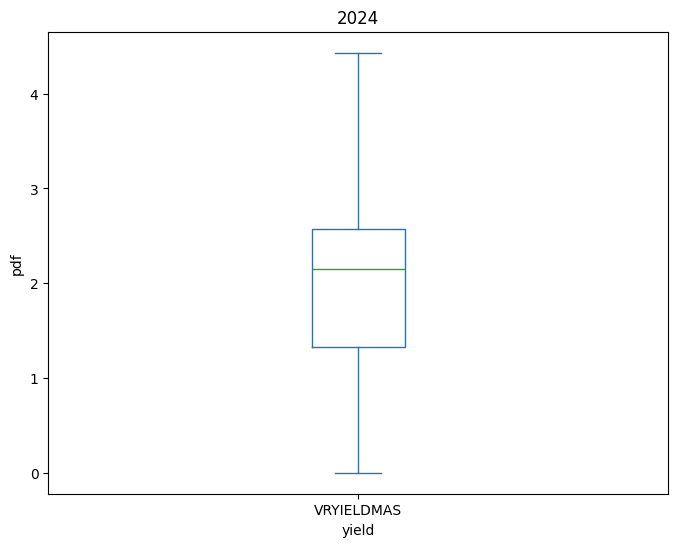

In [161]:
for i, data_frame in enumerate(all_data_frames_new):
    column = 'VRYIELDMAS'
    plt.figure(figsize=(8,6))
    data_frame[column].plot.box()
    plt.title(f"{data_frame['year'][100]}")
    plt.xlabel("yield")
    plt.ylabel("pdf")
    plt.show()

In [118]:
for i, data_frame in enumerate(all_data_frames_new):
    column = 'VRYIELDMAS'
    print(data_frame['year'][100])
    print(data_frame[column].describe())
    print(" ")
    print(" ")
    print(" ")

2018
count    26472.000000
mean         1.201864
std          0.719480
min          0.000000
25%          0.571064
50%          1.391113
75%          1.795620
max          3.175107
Name: VRYIELDMAS, dtype: float64
 
 
 
2020
count    11715.000000
mean         2.860205
std          1.458780
min          0.000000
25%          1.714927
50%          3.202201
75%          3.981492
max          6.708328
Name: VRYIELDMAS, dtype: float64
 
 
 
2021
count    38209.000000
mean         9.774000
std          2.306516
min          3.121749
25%          8.334620
50%         10.044164
75%         11.432910
max         16.385808
Name: VRYIELDMAS, dtype: float64
 
 
 
2022
count    24897.000000
mean         2.600782
std          1.066422
min          0.003155
25%          1.928172
50%          2.905378
75%          3.408583
max          5.641562
Name: VRYIELDMAS, dtype: float64
 
 
 
2023
count    43672.000000
mean        13.920347
std          1.701509
min          8.969360
25%         13.003091
50%  

In [119]:
cropped_data.isna().count()

DISTANCE       185132
SWATHWIDTH     185132
VRYIELDMAS     185132
SECTIONID      185132
Crop           185132
WetMass        185132
Moisture       185132
Time           185132
Heading        185132
VARIETY        185132
Elevation      185132
IsoTime        185132
Machine        185132
xcoord         185132
ycoord         185132
area           185132
CROPNAME_      185132
Organic M      185132
Ca             185132
Mg             185132
Mg_Index       185132
Mn             185132
B              185132
Cu             185132
Mo             185132
Fe             185132
Zn             185132
S              185132
P              185132
P_Index        185132
K              185132
K_Index        185132
Na             185132
pH             185132
C.E.C          185132
year           185132
Name           185132
FUEL           185132
VEHICLSPEED    185132
DRYMATTER      185132
PRODUCTHASH    185132
FIELDREF       185132
dtype: int64

In [201]:
len(cropped_data)

185132

In [202]:
cropped_data.columns

Index(['DISTANCE', 'SWATHWIDTH', 'VRYIELDMAS', 'SECTIONID', 'Crop', 'WetMass',
       'Moisture', 'Time', 'Heading', 'VARIETY', 'Elevation', 'IsoTime',
       'Machine', 'xcoord', 'ycoord', 'area', 'CROPNAME_', 'Organic M', 'Ca',
       'Mg', 'Mg_Index', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S', 'P',
       'P_Index', 'K', 'K_Index', 'Na', 'pH', 'C.E.C', 'year', 'Name', 'FUEL',
       'VEHICLSPEED', 'DRYMATTER', 'PRODUCTHASH', 'FIELDREF'],
      dtype='object')

In [ ]:
clear_cropped_data = cropped_data.drop(columns=['FIELDREF', 'DISTANCE', 'SWATHWIDTH',
                                                 'WetMass', 'Time', 'Heading',
                                                'VARIETY', 'IsoTime', 'Machine', 
                                                'FUEL', 'VEHICLSPEED', 'PRODUCTHASH',
                                                'Name', 'DRYMATTER', 'P_Index', 
                                                'K_Index', 'Mg_Index', "CROPNAME_"])
clear_cropped_data.head()

,VRYIELDMAS,SECTIONID,Crop,Moisture,Elevation,xcoord,ycoord,area,Organic M,Ca,...,Mo,Fe,Zn,S,P,K,Na,pH,C.E.C,year
0,0.000000,499,45,14.38,269.856182,25.839963,48.834206,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018
1,0.186290,499,45,14.41,269.818182,25.839974,48.834226,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018
2,0.000000,499,45,14.44,269.751182,25.839979,48.834244,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018
3,0.143233,499,45,14.45,269.748182,25.839986,48.834261,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018
4,0.000000,499,45,14.24,269.713182,25.839996,48.834278,5.18,9.5,4901.0,...,0.01,35.0,2.9,5.0,5.0,363.0,9.0,8.2,26.9,2018


In [121]:
clear_cropped_data = pd.get_dummies(clear_cropped_data, columns=['Crop'], drop_first=False)

In [122]:
clear_cropped_data.columns

Index(['VRYIELDMAS', 'SECTIONID', 'Moisture', 'Elevation', 'xcoord', 'ycoord',
       'area', 'Organic M', 'Ca', 'Mg', 'Mn', 'B', 'Cu', 'Mo', 'Fe', 'Zn', 'S',
       'P', 'K', 'Na', 'pH', 'C.E.C', 'year', 'Crop_22', 'Crop_34', 'Crop_41',
       'Crop_45', 'Crop_174'],
      dtype='object')

In [123]:
clear_cropped_data.isna().sum()

VRYIELDMAS      0
SECTIONID       0
Moisture        0
Elevation       0
xcoord          0
ycoord          0
area          361
Organic M     361
Ca            361
Mg            361
Mn            361
B             361
Cu            361
Mo            361
Fe            361
Zn            361
S             361
P             361
K             361
Na            361
pH            361
C.E.C         361
year            0
Crop_22         0
Crop_34         0
Crop_41         0
Crop_45         0
Crop_174        0
dtype: int64

In [124]:
clear_cropped_data.tail()

,VRYIELDMAS,SECTIONID,Moisture,Elevation,xcoord,ycoord,area,Organic M,Ca,Mg,...,K,Na,pH,C.E.C,year,Crop_22,Crop_34,Crop_41,Crop_45,Crop_174
185127,0.281828,2373,12.0,289.456031,25.838831,48.828348,4.71,6.0,4779.0,168.0,...,233.0,1.0,7.2,27.9,2024,False,False,False,False,True
185128,0.153946,2373,12.0,289.436031,25.838806,48.828337,4.71,6.0,4779.0,168.0,...,233.0,1.0,7.2,27.9,2024,False,False,False,False,True
185129,0.135194,2373,12.0,289.436031,25.838781,48.828327,4.71,6.0,4779.0,168.0,...,233.0,1.0,7.2,27.9,2024,False,False,False,False,True
185130,0.113808,2373,12.0,289.463031,25.838757,48.828315,4.71,6.0,4779.0,168.0,...,233.0,1.0,7.2,27.9,2024,False,False,False,False,True
185131,0.017662,2373,12.0,289.512031,25.838733,48.828305,4.71,6.0,4779.0,168.0,...,233.0,1.0,7.2,27.9,2024,False,False,False,False,True


In [125]:
clear_cropped_data.fillna(clear_cropped_data.mean(), inplace=True)

In [126]:
len(clear_cropped_data)

185132

In [ ]:
clear_cropped_data.to_csv('all_yields.csv', index=False)

In [127]:
final_df = clear_cropped_data.merge(
    wether_table,
    on='year',
    how='left'
)

In [128]:
len(final_df)

185132

In [129]:
final_df

,VRYIELDMAS,SECTIONID,Moisture,Elevation,xcoord,ycoord,area,Organic M,Ca,Mg,...,mean_cloudcover_month_7,mean_cloudcover_month_8,mean_cloudcover_month_9,mean_cloudcover_month_10,std_cloudcover_month_5,std_cloudcover_month_6,std_cloudcover_month_7,std_cloudcover_month_8,std_cloudcover_month_9,std_cloudcover_month_10
0,0.000000,499,14.38,269.856182,25.839963,48.834206,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
1,0.186290,499,14.41,269.818182,25.839974,48.834226,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
2,0.000000,499,14.44,269.751182,25.839979,48.834244,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
3,0.143233,499,14.45,269.748182,25.839986,48.834261,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
4,0.000000,499,14.24,269.713182,25.839996,48.834278,5.18,9.5,4901.0,100.0,...,67.474194,48.309677,59.550000,47.425806,24.902733,24.864623,18.293386,24.280985,24.648883,34.17580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185127,0.281828,2373,12.00,289.456031,25.838831,48.828348,4.71,6.0,4779.0,168.0,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.08093
185128,0.153946,2373,12.00,289.436031,25.838806,48.828337,4.71,6.0,4779.0,168.0,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.08093
185129,0.135194,2373,12.00,289.436031,25.838781,48.828327,4.71,6.0,4779.0,168.0,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.08093
185130,0.113808,2373,12.00,289.463031,25.838757,48.828315,4.71,6.0,4779.0,168.0,...,56.635484,43.606452,53.983333,61.748387,24.192672,21.986699,22.469365,27.514880,35.865708,33.08093


In [130]:
final_df.to_csv('all_yields_.csv', index=False)